In [1]:
import pandas as pd
import numpy as np
from scipy.stats import loguniform, uniform
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import RocCurveDisplay

In [2]:
X_train = pd.read_csv("Dataset/X_train.csv", index_col=False)
X_test = pd.read_csv("Dataset/X_test.csv", index_col=False)
y_train = pd.read_csv("Dataset/y_train.csv", index_col=False)
y_test = pd.read_csv("Dataset/y_test.csv", index_col=False)

# Convert single-column DataFrames into 1D Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [3]:
len(X_train), len(y_train), len(X_test), len(y_test)

(5634, 5634, 1409, 1409)

In [4]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [5]:
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the follo

In [6]:
model.score(X_test, y_test)

0.7991483321504613

In [7]:
y_preds = model.predict(X_test)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1035
           1       0.58      0.86      0.69       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.84      0.80      0.81      1409



## Hyperparameter tuning

### RandomizedSearchCV

In [8]:
param_distributions = {
    'C': loguniform(1e-4, 1e2),
    'l1_ratio': uniform(0, 1),
    'solver': ['saga'],
    'max_iter': [1000, 2000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=30,                                                
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001C0AA238980>, 'l1_ratio': <scipy.stats....001C0AA18A350>, 'max_iter': [1000, 2000], 'solver': ['saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to

In [9]:
random_search.score(X_test, y_test)

0.7991483321504613

In [10]:
random_search.best_params_

{'C': np.float64(7.085721663941605),
 'l1_ratio': np.float64(0.3046137691733707),
 'max_iter': 1000,
 'solver': 'saga'}

## Hyperparamter Tuning with GridSearchCV

In [11]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
    'solver': ['saga'],
    'class_weight': ['balanced'],
    'max_iter': [1000, 2000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,      
    cv=cv,
    n_jobs=-1,
    verbose=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': ['balanced'], 'l1_ratio': [0.0, 0.25, ...], 'max_iter': [1000, 2000], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :

In [12]:
# Evaluate the grid search LogisticRegression model
grid_search.score(X_test, y_test)

0.7991483321504613

In [13]:
# Check the best hyperparameters
grid_search.best_params_

{'C': 10,
 'class_weight': 'balanced',
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'solver': 'saga'}

## Evaluating tuned machine learning model

### RandomSearchCV

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

In [14]:
y_preds = random_search.predict(X_test)
y_preds

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [15]:
y_test

0       0
1       0
2       0
3       0
4       0
       ..
1404    0
1405    0
1406    0
1407    0
1408    0
Name: Churn Label, Length: 1409, dtype: int64

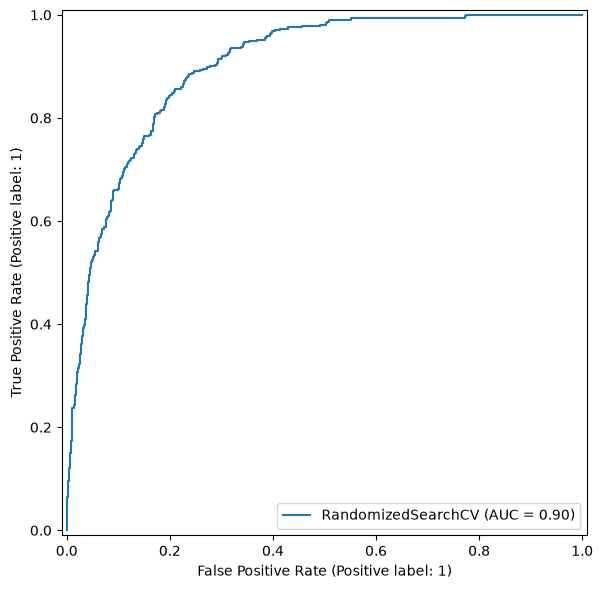

In [16]:
# Plot ROC curve and calculate and calculate AUC metric
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    random_search,
    X_test,
    y_test,
    ax=ax
)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

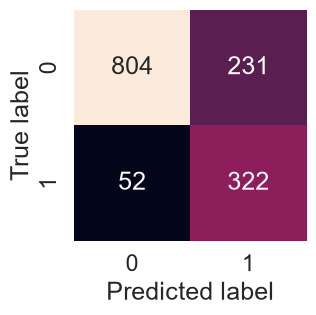

In [17]:
# Confusion matrix
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                    annot=True,
                    fmt="d",
                    cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
plot_conf_mat(y_test, y_preds)

### Classification Report

In [18]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1035
           1       0.58      0.86      0.69       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.84      0.80      0.81      1409



In [19]:
random_search.best_params_

{'C': np.float64(7.085721663941605),
 'l1_ratio': np.float64(0.3046137691733707),
 'max_iter': 1000,
 'solver': 'saga'}

In [20]:
# Create a new classifier with best parameters
random_search_model = LogisticRegression(class_weight='balanced',
                           random_state=42,
                           C=5.141096648805748,
                           l1_ratio=0.19967378215835974,
                           max_iter=1000,
                           solver='saga')

In [21]:
# Cross-validated accuracy
random_search_cv_acc = cross_val_score(random_search_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="accuracy")
random_search_cv_acc = np.mean(random_search_cv_acc)
random_search_cv_acc

np.float64(0.796589761087847)

In [22]:
# Cross-validated precision
random_search_cv_precision = cross_val_score(random_search_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="precision")
random_search_cv_precision = np.mean(random_search_cv_precision)
random_search_cv_precision

np.float64(0.5799046154586411)

In [23]:
# Cross-validated recall
random_search_cv_recall = cross_val_score(random_search_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="recall")
random_search_cv_recall = np.mean(random_search_cv_recall)
random_search_cv_recall

np.float64(0.8501672240802675)

In [24]:
# Cross-validated f1-score
random_search_cv_f1 = cross_val_score(random_search_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="f1")
random_search_cv_f1 = np.mean(random_search_cv_f1)
random_search_cv_f1

np.float64(0.6893568487746624)

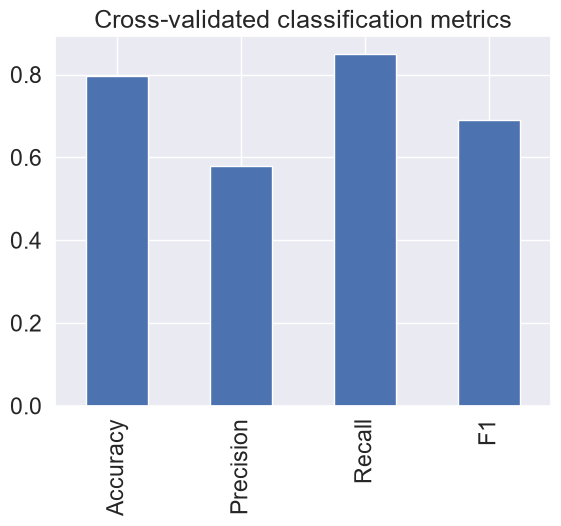

In [25]:
# Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": random_search_cv_acc,
                          "Precision": random_search_cv_precision,
                          "Recall": random_search_cv_recall,
                          "F1": random_search_cv_f1},
                         index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False);

### GridSearchCV

In [26]:
y_preds_grid = grid_search.predict(X_test)
y_preds_grid

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [27]:
y_test

0       0
1       0
2       0
3       0
4       0
       ..
1404    0
1405    0
1406    0
1407    0
1408    0
Name: Churn Label, Length: 1409, dtype: int64

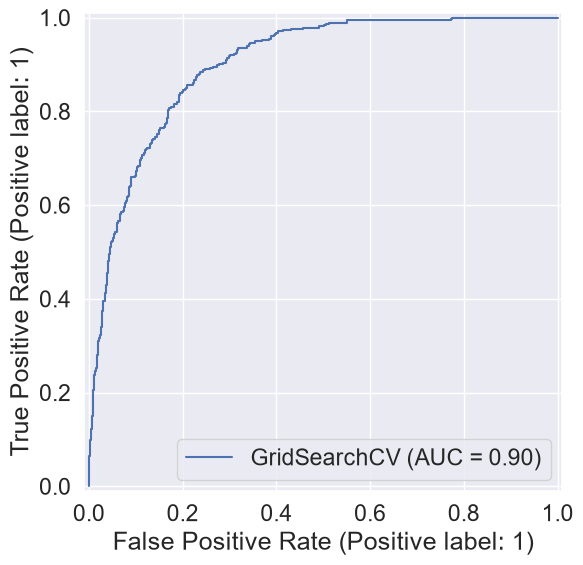

In [28]:
# Plot ROC curve and calculate and calculate AUC metric
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    grid_search,
    X_test,
    y_test,
    ax=ax
)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

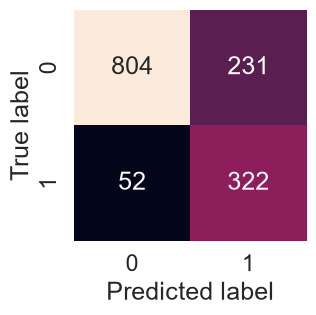

In [29]:
plot_conf_mat(y_test, y_preds_grid)

In [30]:
print(classification_report(y_test, y_preds_grid))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1035
           1       0.58      0.86      0.69       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.84      0.80      0.81      1409



In [31]:
grid_search.best_params_

{'C': 10,
 'class_weight': 'balanced',
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'solver': 'saga'}

In [32]:
# Create a new classifier with best parameters
grid_model = LogisticRegression(class_weight='balanced',
                           random_state=42,
                           C=10,
                           l1_ratio=0.0,
                           max_iter=1000,
                           solver='saga')

In [33]:
# Cross-validated accuracy
grid_cv_acc = cross_val_score(grid_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="accuracy")
grid_cv_acc = np.mean(grid_cv_acc)
grid_cv_acc

np.float64(0.7960573742200564)

In [34]:
# Cross-validated precision
grid_cv_precision = cross_val_score(grid_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="precision")
grid_cv_precision = np.mean(grid_cv_precision)
grid_cv_precision

np.float64(0.5790943785759533)

In [35]:
# Cross-validated recall
grid_cv_recall = cross_val_score(grid_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="recall")
grid_cv_recall = np.mean(grid_cv_recall)
grid_cv_recall

np.float64(0.8501672240802675)

In [36]:
# Cross-validated f1-score
grid_cv_f1 = cross_val_score(grid_model,
                        X_train,
                        y_train,
                        cv=5,
                        scoring="f1")
grid_cv_f1 = np.mean(grid_cv_f1)
grid_cv_f1

np.float64(0.6887918667701101)

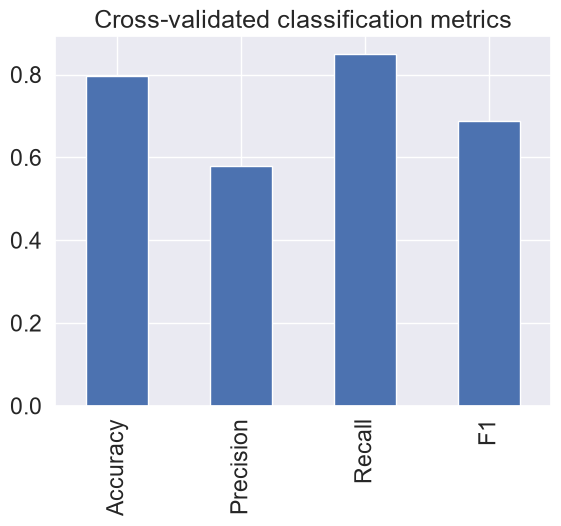

In [37]:
# Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": grid_cv_acc,
                          "Precision": grid_cv_precision,
                          "Recall": grid_cv_recall,
                          "F1": grid_cv_f1},
                         index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False);

### Compare model performance

In [38]:
print("Grid CV score:", grid_search.best_score_)
print("Random CV score:", random_search.best_score_)

Grid CV score: 0.7955319219355053
Random CV score: 0.7955319219355051


In [39]:
grid_pred = grid_search.best_estimator_.predict(X_test)
random_pred = random_search.best_estimator_.predict(X_test)

print(np.array_equal(grid_pred, random_pred))

True


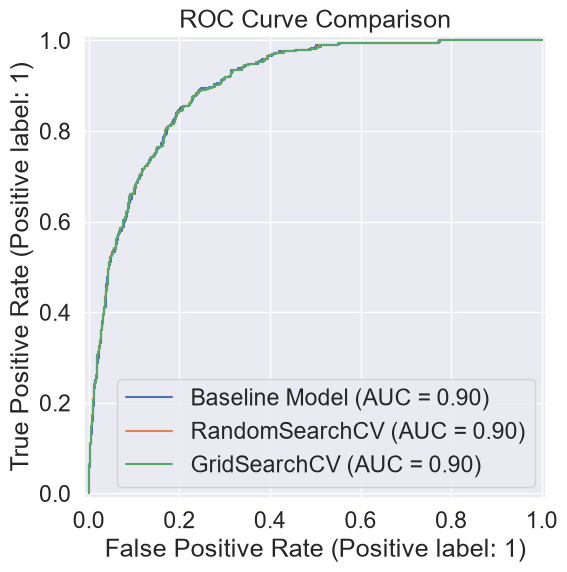

In [40]:
model = LogisticRegression(class_weight='balanced', random_state=42)
random_search_model = LogisticRegression(class_weight='balanced',
                           random_state=42,
                           C=5.141096648805748,
                           l1_ratio=0.19967378215835974,
                           max_iter=1000,
                           solver='saga')
grid_model = LogisticRegression(class_weight='balanced',
                           random_state=42,
                           C=10,
                           l1_ratio=0.0,
                           max_iter=1000,
                           solver='saga')
model.fit(X_train, y_train)
random_search_model.fit(X_train, y_train)
grid_model.fit(X_train, y_train)

# Create a single plot figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Baseline Model
RocCurveDisplay.from_estimator(
    model, X_test, y_test, ax=ax, name="Baseline Model"
)

# Plot RandomizedSearchCV Best Estimator
RocCurveDisplay.from_estimator(
    random_search.best_estimator_, X_test, y_test, ax=ax, name="RandomSearchCV"
)

# Plot GridSearchCV Best Estimator
RocCurveDisplay.from_estimator(
    grid_search.best_estimator_, X_test, y_test, ax=ax, name="GridSearchCV"
)

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

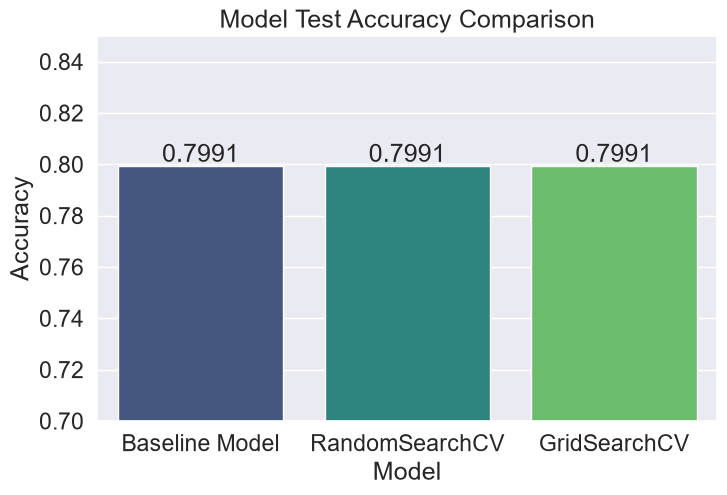

In [41]:
# Calculate test scores
baseline_score = model.score(X_test, y_test)
random_score = random_search.score(X_test, y_test)
grid_score = grid_search.score(X_test, y_test)

# Organize scores into a DataFrame
df_scores = pd.DataFrame({
    'Model': ['Baseline Model', 'RandomSearchCV', 'GridSearchCV'],
    'Accuracy Score': [baseline_score, random_score, grid_score]
})

# Plot Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Model', 
    y='Accuracy Score', 
    data=df_scores, 
    hue='Model', 
    palette='viridis', 
    legend=False
)

# Add score labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), textcoords='offset points'
    )

plt.ylim(0.7, 0.85)
plt.title("Model Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

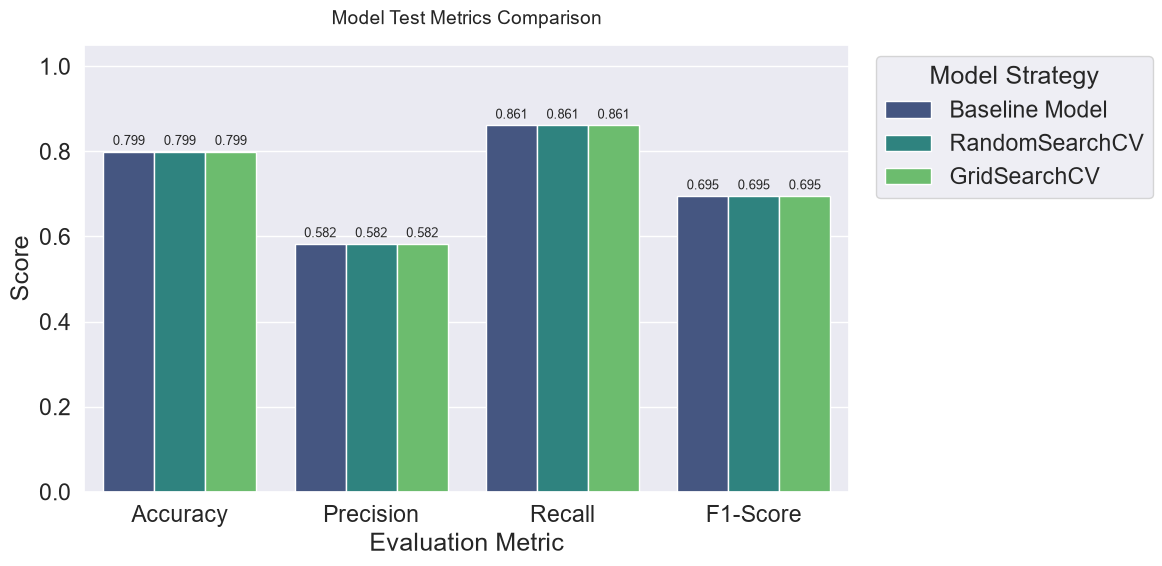

In [42]:
# Define dictionary of models to evaluate
models = {
    'Baseline Model': model,
    'RandomSearchCV': random_search.best_estimator_,
    'GridSearchCV': grid_search.best_estimator_
}

# Collect metrics for each model
records = []
for name, clf in models.items():
    preds = clf.predict(X_test)
    records.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

# Convert to DataFrame
df_metrics = pd.DataFrame(records)

# Melt DataFrame into long form for Seaborn multi-metric plotting
df_melted = pd.melt(
    df_metrics, 
    id_vars=['Model'], 
    var_name='Metric', 
    value_name='Score'
)

# Plot Grouped Bar Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_melted, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette='viridis'
)

# Add score labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(
            f"{height:.3f}", 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            xytext=(0, 3), textcoords='offset points',
            fontsize=9
        )

plt.ylim(0, 1.05)
plt.title("Model Test Metrics Comparison", fontsize=14, pad=15)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.legend(title="Model Strategy", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
model.coef_

array([[ 0.23806909, -0.54262563, -1.5222775 , -0.71241256,  0.0085967 ,
         0.05728743,  1.83508313, -0.01745924,  0.08337478, -0.00552387,
        -0.59300563, -0.04259147, -0.04973372, -0.81209162,  0.71976644,
        -0.02692272,  0.726758  , -0.10850689, -0.41512675, -0.41638304,
         0.14785622,  0.62492009, -0.71724528, -0.09755702,  0.00523183,
         0.10814557, -0.08157396, -0.84551317,  0.72661638,  0.13046716,
        -0.22279235,  0.10006633, -0.19239151, -0.05178999, -0.0405352 ,
         0.12373395, -0.21605914, -0.01333905, -0.07898613,  0.1288811 ,
        -0.22120628, -0.2743767 ,  0.18205152, -0.21930586,  0.12698068,
         1.33480163, -0.07463763, -1.35248918, -0.21953415,  0.12720896,
        -0.04142336, -0.45534775,  0.40444593, -0.01334371, -0.33227052,
        -0.08521549,  0.33850453]])

In [45]:
# Match coef's of features to columns
feature_dict = dict(zip(X_train.columns, list(model.coef_[0])))
feature_dict

{'num__Age': np.float64(0.23806908852652228),
 'num__Number of Dependents': np.float64(-0.5426256263538823),
 'num__Number of Referrals': np.float64(-1.5222774997996744),
 'num__Tenure in Months': np.float64(-0.7124125626066601),
 'num__Avg Monthly Long Distance Charges': np.float64(0.008596701075879216),
 'num__Avg Monthly GB Download': np.float64(0.05728743134397974),
 'num__Monthly Charge': np.float64(1.8350831310670328),
 'num__Total Refunds': np.float64(-0.01745924468303931),
 'num__Total Extra Data Charges': np.float64(0.08337477931132181),
 'num__CLTV': np.float64(-0.005523870388651466),
 'num__Total Services': np.float64(-0.5930056259324687),
 'cat__Gender_Female': np.float64(-0.04259146674519471),
 'cat__Gender_Male': np.float64(-0.04973371688777539),
 'cat__Married_No': np.float64(-0.8120916219005714),
 'cat__Married_Yes': np.float64(0.7197664382676017),
 'cat__Offer_No Offer': np.float64(-0.026922715340228935),
 'cat__Offer_Offer A': np.float64(0.7267580043325821),
 'cat__Of

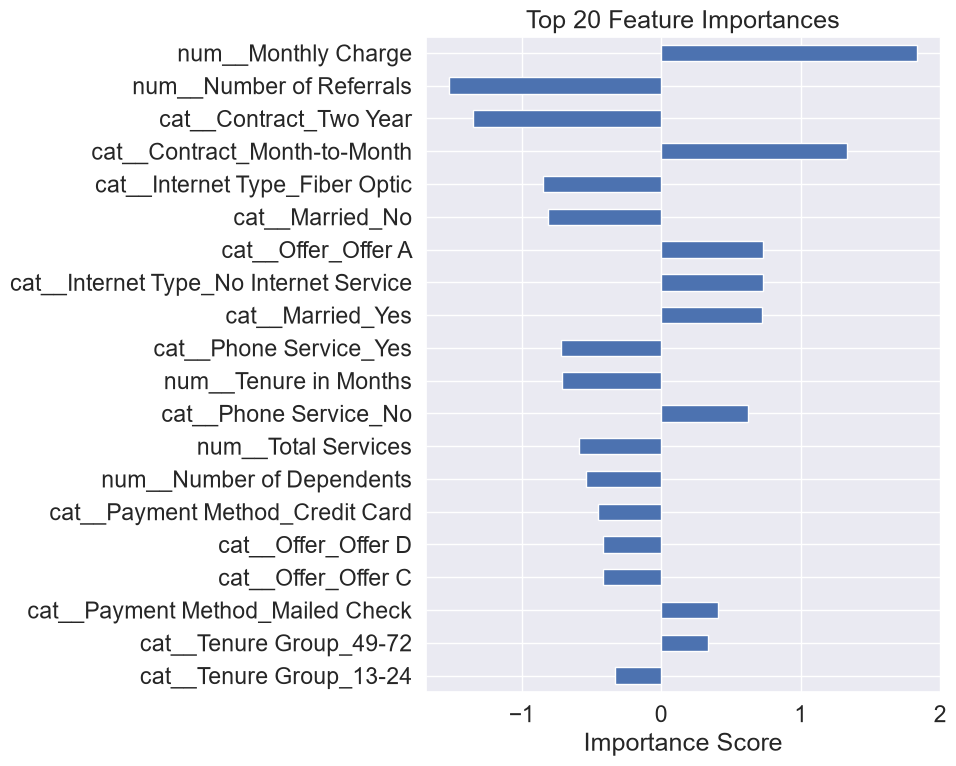

In [48]:
# Sort features by absolute importance and take top 20
top_features = feature_df.T.reindex(
    feature_df.T[0].abs().sort_values(ascending=True).index
).tail(20)

# Plot top 20 features
top_features.plot.barh(figsize=(10, 8), title="Top 20 Feature Importances", legend=False)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Experiment summary and key findings

This notebook evaluated a logistic regression churn model using:
- a baseline `LogisticRegression` model with `class_weight='balanced'`
- `RandomizedSearchCV` hyperparameter tuning
- `GridSearchCV` hyperparameter tuning
- 5-fold `StratifiedKFold` cross-validation
- ROC curve, confusion matrix, and classification report comparisons

### Results

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Baseline Model | 0.7991 | 0.5823 | 0.8610 | 0.6947 |
| RandomSearchCV | 0.7991 | 0.5823 | 0.8610 | 0.6947 |
| GridSearchCV | 0.7991 | 0.5823 | 0.8610 | 0.6947 |

### Important observations

- The tuned models produced the same final predictions and evaluation metrics as the baseline model on the test set.
- This suggests the baseline logistic regression model was already strong for this dataset, and the tuned hyperparameters did not produce a meaningful improvement.
- The model captures churn well in terms of recall (`0.8610`), meaning it correctly identifies most actual churn cases.
- Precision is lower (`0.5823`), so the model still produces a noticeable number of false positives.
- Because the class imbalance is handled with `class_weight='balanced'`, the model favors better detection of the minority positive churn class, which is useful for churn prediction even though precision remains moderate.

### Overall conclusion

For this churn dataset, the balanced logistic regression model performs acceptably and the tuning step does not materially improve the test performance. The main trade-off is between identifying churn customers (high recall) and limiting false alarms (precision).